# Eigenvalues and Eigenvectors

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute eigenvalues and eigenvectors
- Interpret spectral properties of matrices
- Apply eigendecomposition to dimensionality reduction

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 06 "Developing Simple Supervised and Unsupervised Learning Models" — you clustered 150 iris flowers there without ever asking which directions in the data carry the variance; eigenvectors answer that.

**Used later in:** Course 04 (AIAT 114) — Unit 4, lesson 03 "Principal Component Analysis (PCA)" — sklearn returns exactly these eigenvectors as its components.

---


---

## 📌 Real case: the eigenvector that ranked the web

In 1998 Sergey Brin and Larry Page described a search engine whose ranking signal was a single vector.
Model a random surfer who follows links and, with probability 1 − *d* (the **damping factor**,
conventionally **0.85**), jumps to a random page instead. The long-run fraction of time that surfer
spends on each page is exactly the **dominant eigenvector** of the web's link matrix, rescaled so each
column sums to one. That vector is PageRank. Brin and Page reported that on a link graph of
**322 million links** the computation converged to a usable tolerance in **52 iterations** of the power
method: the whole ranking of the early web, from one eigenvector of one enormous sparse matrix.

**What goes wrong without this.** Rank pages by counting inbound links and anyone can buy a top result
by creating a thousand pages that link to their own. The eigenvector answer is self-referential in a way
counting is not — a link from an important page counts more, and "important" is defined by the same
equation. That fixed point *is* what an eigenvector is, and it is why "solve for the eigenvector" was
worth building a company on.

**The same reasoning appears elsewhere:** citation ranking of scientific papers; identifying the most
structurally central account in a fraud ring; spectral clustering, which splits a graph using the
eigenvector of its Laplacian.


# Eigenvalues and Eigenvectors

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Vectors and Matrices Basics** - Understand matrices
- ✅ **Example 2: Matrix Operations** - Understand matrix multiplication
- ✅ **Basic understanding**: What are transformations?

**If you haven't completed these**, you might struggle with:
- Understanding eigenvalue decomposition
- Understanding why eigenvalues matter
- Using eigenvalues in ML applications

---

## 🔗 Where This Notebook Fits

**This is the THIRD example** - it uses concepts from Examples 1-2!

**Why this example THIRD?**
- **Before** you can understand eigenvalues, you need matrix operations (Example 2)
- **Before** you can do PCA, you need eigenvalues (Module 04)
- **Before** you can reduce dimensions, you need to find principal directions

**Builds on**: Examples 1-2 (matrices and operations)

**Leads to**: 
- 📓 Module 04: PCA (uses eigenvalue decomposition)
- 📓 Advanced ML: Dimensionality reduction techniques

---

## The Story: Understanding Before Using

Imagine you're analyzing a dataset. **Before** PCA, you have many features and don't know which matter most. **After** finding eigenvalues, you discover the most important directions in your data - the directions with most variance!

Same with machine learning: **Before** dimensionality reduction, we have high-dimensional data. **After** eigenvalue decomposition, we find the principal components that capture most information!

---

## Why This Concept Matters

### Why Eigenvalues/Eigenvectors Matter

**WHY** are eigenvalues and eigenvectors important?

1. **Dimensionality Reduction (PCA)**:
   - **WHY**: Reduce data dimensions while keeping information
   - **HOW**: Eigenvectors show directions of maximum variance
   - **AFTER**: Smaller datasets, faster training

2. **Data Understanding**:
   - **WHY**: Find most important directions in data
   - **HOW**: Eigenvalues show variance explained
   - **AFTER**: Better feature selection

3. **Matrix Decomposition**:
   - **WHY**: Understand matrix structure
   - **HOW**: Eigenvalue decomposition reveals properties
   - **AFTER**: Enables advanced ML techniques

## Learning Objectives
1. Compute eigenvalues and eigenvectors
2. Understand what they represent
3. See how they're used in PCA
4. Visualize principal directions
5. Understand variance explained
6. Apply to dimensionality reduction

---

## Step 1: Import necessary libraries

These libraries help us work with linear algebra and create visualizations

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: load the libraries this lesson relies on.
# NumPy computes eigenvalues/eigenvectors, pandas reads the real dataset,
# and Matplotlib shows what the eigenvectors mean geometrically.

import numpy as np  # For linear algebra operations
import pandas as pd  # For loading the real crime dataset
import matplotlib.pyplot as plt  # For creating plots and visualizations

from pathlib import Path


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


# Confirm the environment is ready before any math starts.
print('✅ Libraries imported successfully!')
print('\n📚 What each library does:')
print('   - numpy: Linear algebra operations (vectors, matrices, math)')
print('   - pandas: Load the real dataset from disk')
print('   - matplotlib: Create plots and visualizations')


✅ Libraries imported successfully!

📚 What each library does:
   - numpy: Linear algebra operations (vectors, matrices, math)
   - pandas: Load the real dataset from disk
   - matplotlib: Create plots and visualizations


---

## Part 1: Setting the Scene

**BEFORE**: We have concepts but don't know how to implement them.

**AFTER**: We'll implement and understand how this concept works in ML!

**Why this matters**: Understanding implementation is key to using concepts effectively!

## Step 1: Computing Eigenvalues and Eigenvectors

**BEFORE**: We have a covariance matrix but don't know the important directions.

**AFTER**: We'll compute eigenvalues and eigenvectors to find directions of maximum variance!

**Why eigenvalues?** They tell us which directions in the data contain the most information!

---

### 📖 Quick recap: variance, covariance, and the covariance matrix

(Formally taught in Unit 3, notebook 03 — here is the minimum you need now.)

- **Variance** of a feature x: the average squared distance from its mean, Var(x) = mean((x − x̄)²). It measures how spread out the feature is.
- **Covariance** of two features x and y: Cov(x, y) = mean((x − x̄)(y − ȳ)). Positive → they rise together; negative → one rises as the other falls; near 0 → unrelated.
- **Covariance matrix** for 2 features — a 2×2 matrix collecting all of these:

  |       | x         | y         |
  |-------|-----------|-----------|
  | **x** | Var(x)    | Cov(x, y) |
  | **y** | Cov(x, y) | Var(y)    |

`np.cov(data.T)` computes exactly this matrix. The eigen-analysis below then asks: *in which directions does this data actually spread?*

In [2]:
# Example 1: Computing Eigenvalues and Eigenvectors on REAL data
# WHY: Find the principal directions in a real feature matrix
# HOW: Eigenvalue decomposition of the covariance matrix
#
# Dataset: USArrests - violent-crime rates recorded for all 50 US states (1973),
# expressed as arrests per 100,000 residents. This is the dataset PCA is classically
# taught on, and every number in it was actually measured.

arrests = pd.read_csv(data_path("crime_statistics_original_50.csv"))
feature_names = ["Murder", "Assault"]

print("Dataset: USArrests (arrests per 100,000 residents, 50 US states)")
print(arrests[["State"] + feature_names].head())
print(f"\nThe two features live on very different scales -> "
      f"Murder spans {arrests['Murder'].min():.1f}-{arrests['Murder'].max():.1f}, "
      f"Assault spans {arrests['Assault'].min()}-{arrests['Assault'].max()}")

# Standardize each feature (subtract the mean, divide by the standard deviation).
# WHY this matters: Assault is counted in the hundreds while Murder is in the teens.
# On the raw numbers the covariance matrix would just report that Assault has the
# bigger units, and PCA would describe the measuring stick instead of the structure.
raw = arrests[feature_names].to_numpy(dtype=float)
data = (raw - raw.mean(axis=0)) / raw.std(axis=0, ddof=1)

# Compute covariance matrix (shows how features vary together)
cov_matrix = np.cov(data.T)

# Eigenvalue decomposition
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("\nExample 1: Eigenvalue Decomposition")
print("=" * 60)
print(f"Standardized data shape: {data.shape}  ({data.shape[0]} states, {data.shape[1]} features)")
print("Covariance matrix (equals the correlation matrix, because the data is standardized):")
print(cov_matrix)
print(f"\nEigenvalues: {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")
print("\n💡 WHY: Eigenvalues show how much variance each direction explains!")
print("💡 HOW: Larger eigenvalue = more variance in that direction!")


Dataset: USArrests (arrests per 100,000 residents, 50 US states)
        State  Murder  Assault
0     Alabama    13.2      236
1      Alaska    10.0      263
2     Arizona     8.1      294
3    Arkansas     8.8      190
4  California     9.0      276

The two features live on very different scales -> Murder spans 0.8-17.4, Assault spans 45-337

Example 1: Eigenvalue Decomposition
Standardized data shape: (50, 2)  (50 states, 2 features)
Covariance matrix (equals the correlation matrix, because the data is standardized):
[[1.         0.80187331]
 [0.80187331 1.        ]]

Eigenvalues: [0.19812669 1.80187331]
Eigenvectors:
[[-0.70710678 -0.70710678]
 [ 0.70710678 -0.70710678]]

💡 WHY: Eigenvalues show how much variance each direction explains!
💡 HOW: Larger eigenvalue = more variance in that direction!


## Step 2: Understanding Results

**BEFORE**: We computed eigenvalues but don't know what they mean.

**AFTER**: We'll interpret eigenvalues to understand which directions matter most!

**Why interpretation?** We need to know which components to keep for dimensionality reduction!

In [3]:
# Example 2: Understanding Eigenvalues
# WHY: Know which directions matter
# HOW: Larger eigenvalues = more variance

# Sort by eigenvalue (largest first)
idx = eigenvalues.argsort()[::-1]
eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]

# Eigenvectors are only defined up to a sign flip: if v is an eigenvector, so is -v.
# Fix a convention so the arrows and the state ranking below read naturally -
# make each component's largest entry positive, so "higher score = higher crime rate".
for j in range(eigenvectors_sorted.shape[1]):
    if eigenvectors_sorted[np.argmax(np.abs(eigenvectors_sorted[:, j])), j] < 0:
        eigenvectors_sorted[:, j] *= -1

# Calculate variance explained
total_variance = eigenvalues_sorted.sum()
variance_explained = eigenvalues_sorted / total_variance * 100

print("\nExample 2: Variance Explained by Each Component")
print("=" * 60)
for i, (val, var) in enumerate(zip(eigenvalues_sorted, variance_explained)):
    print(f"Component {i+1}:")
    print(f"  - Eigenvalue: {val:.4f}")
    print(f"  - Variance explained: {var:.2f}%")
    print(f"  - Eigenvector: {eigenvectors_sorted[:, i]}")
print(f"\n💡 WHY: This tells us which components to keep!")
print(f"💡 HOW: Keep components with highest variance explained!")


Example 2: Variance Explained by Each Component
Component 1:
  - Eigenvalue: 1.8019
  - Variance explained: 90.09%
  - Eigenvector: [0.70710678 0.70710678]
Component 2:
  - Eigenvalue: 0.1981
  - Variance explained: 9.91%
  - Eigenvector: [ 0.70710678 -0.70710678]

💡 WHY: This tells us which components to keep!
💡 HOW: Keep components with highest variance explained!


## Step 3: Application to PCA

**BEFORE**: We have high-dimensional data with many features.

**AFTER**: We'll use eigenvalues to reduce dimensions while keeping most information!

**Why PCA?** It uses eigenvalues to find the most important directions and project data onto them!

In [4]:
# Example 3: PCA Application
# WHY: Reduce dimensions efficiently
# HOW: Use top k eigenvectors (principal components)

# Select top component (largest eigenvalue)
top_component = eigenvectors_sorted[:, 0]  # First principal component

# Project data onto principal component
data_projected = data @ top_component

print("\nExample 3: Dimensionality Reduction with PCA")
print("=" * 60)
print(f"Original data shape: {data.shape} ({data.shape[0]} states, {data.shape[1]} features)")
print(f"Projected data shape: {data_projected.shape} ({data_projected.shape[0]} states, 1 feature)")
print(f"\nVariance kept: {variance_explained[0]:.2f}%")
print(f"\n💡 WHY: Reduced from 2D to 1D while keeping {variance_explained[0]:.2f}% of variance!")
print(f"💡 HOW: Projected data onto direction of maximum variance!")
print("💡 MEANING: because murder and assault rates rise and fall together across states,")
print("   PC1 acts as a single 'violent-crime level' score for each state.")

# Rank the states along that one combined axis.
order = np.argsort(data_projected)
print(f"\nLowest on PC1:  {', '.join(arrests['State'].iloc[order[:5]])}")
print(f"Highest on PC1: {', '.join(arrests['State'].iloc[order[-5:][::-1]])}")



Example 3: Dimensionality Reduction with PCA
Original data shape: (50, 2) (50 states, 2 features)
Projected data shape: (50,) (50 states, 1 feature)

Variance kept: 90.09%

💡 WHY: Reduced from 2D to 1D while keeping 90.09% of variance!
💡 HOW: Projected data onto direction of maximum variance!
💡 MEANING: because murder and assault rates rise and fall together across states,
   PC1 acts as a single 'violent-crime level' score for each state.

Lowest on PC1:  North Dakota, Vermont, New Hampshire, Iowa, Wisconsin
Highest on PC1: Florida, North Carolina, Mississippi, South Carolina, Georgia


### 🧪 Does standardizing before PCA change the answer?

Baseline: eigen-decompose the covariance matrix of the **raw** arrests-per-100,000 numbers.
Change one thing: standardize both features first — which is what the cells above quietly did.
Measure: where the first principal component points, and how much variance it claims.

In [5]:
# Comparative experiment: raw covariance vs standardized covariance, same 50 states.

raw_features = arrests[feature_names].to_numpy(dtype=float)                 # untouched units
std_features = (raw_features - raw_features.mean(axis=0)) / raw_features.std(axis=0)

for label, M in [("RAW units (arrests per 100,000)", raw_features),
                 ("STANDARDIZED (each feature mean 0, std 1)", std_features)]:
    cov = np.cov(M, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)          # eigh: a covariance matrix is symmetric
    order = vals.argsort()[::-1]              # largest eigenvalue first
    vals, vecs = vals[order], vecs[:, order]
    if vecs[np.argmax(np.abs(vecs[:, 0])), 0] < 0:
        vecs[:, 0] *= -1                      # fix the sign so the loadings read naturally
    print(label)
    print(f"   feature variances : {feature_names[0]}={cov[0, 0]:9.2f}   {feature_names[1]}={cov[1, 1]:9.2f}")
    print(f"   PC1 direction     : {vecs[0, 0]:+.3f} x {feature_names[0]}   {vecs[1, 0]:+.3f} x {feature_names[1]}")
    print(f"   variance explained by PC1: {100 * vals[0] / vals.sum():.2f}%")
    print()

print("Conclusion the numbers support: on the raw scale Assault's variance is hundreds of times")
print("Murder's, so PC1 lines up almost exactly with the Assault axis and reports a")
print("variance-explained figure that LOOKS spectacular. It is measuring the choice of units, not")
print("a pattern in crime. Standardizing first is what turns PC1 into a statement about the two")
print("crimes rather than about the size of the numbers used to record them.")

RAW units (arrests per 100,000)
   feature variances : Murder=    18.97   Assault=  6945.17
   PC1 direction     : +0.042 x Murder   +0.999 x Assault
   variance explained by PC1: 99.90%

STANDARDIZED (each feature mean 0, std 1)
   feature variances : Murder=     1.02   Assault=     1.02
   PC1 direction     : +0.707 x Murder   +0.707 x Assault
   variance explained by PC1: 90.09%

Conclusion the numbers support: on the raw scale Assault's variance is hundreds of times
Murder's, so PC1 lines up almost exactly with the Assault axis and reports a
variance-explained figure that LOOKS spectacular. It is measuring the choice of units, not
a pattern in crime. Standardizing first is what turns PC1 into a statement about the two
crimes rather than about the size of the numbers used to record them.


---

## 📊 Visualization

Visualizing the concept helps understand it better:

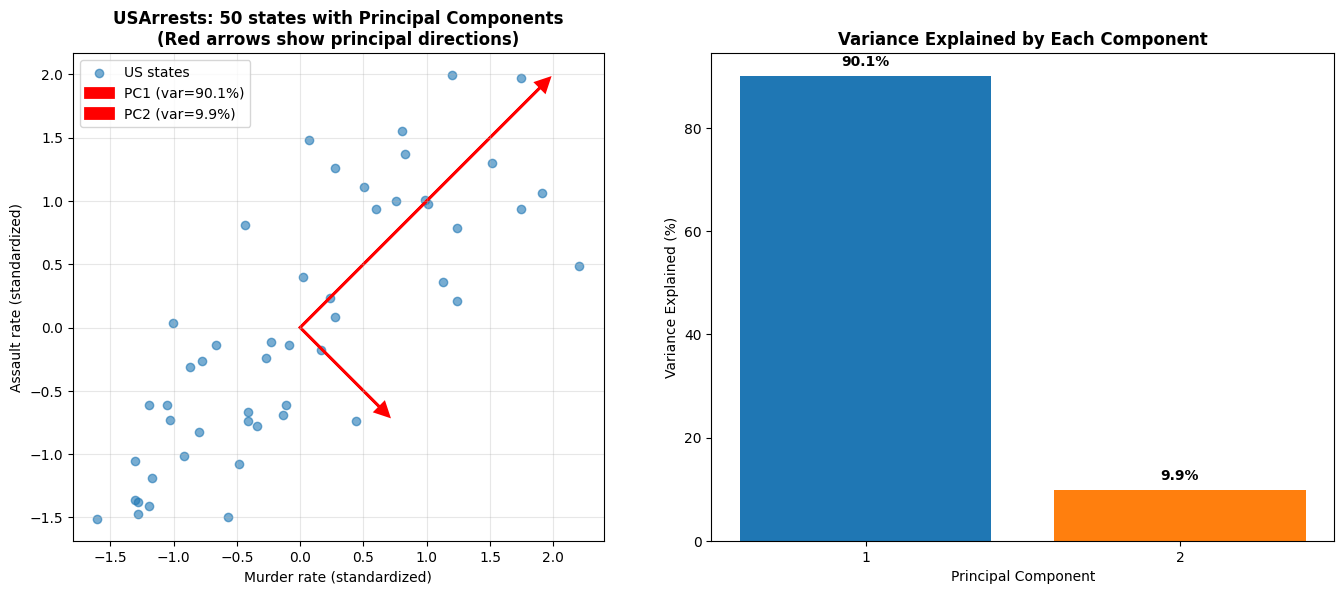


📊 Eigenvalue Visualization:
  - Left: Data with principal component directions (red arrows)
  - Right: Variance explained by each component
  - This is HOW PCA finds important directions!


In [6]:
# Visualize eigenvalues and eigenvectors
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Data with eigenvectors
axes[0].scatter(data[:, 0], data[:, 1], alpha=0.6, label='US states')
# Plot eigenvectors scaled by eigenvalues
for i in range(2):
    eigenvec = eigenvectors_sorted[:, i] * np.sqrt(eigenvalues_sorted[i]) * 2
    axes[0].arrow(0, 0, eigenvec[0], eigenvec[1], 
                  head_width=0.1, head_length=0.1, fc='red', ec='red', linewidth=2,
                  label=f'PC{i+1} (var={variance_explained[i]:.1f}%)')
axes[0].set_xlabel('Murder rate (standardized)')
axes[0].set_ylabel('Assault rate (standardized)')
axes[0].set_title('USArrests: 50 states with Principal Components\n(Red arrows show principal directions)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

# Plot 2: Variance explained
axes[1].bar(range(1, 3), variance_explained, color=['#1f77b4', '#ff7f0e'])
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained (%)')
axes[1].set_title('Variance Explained by Each Component', fontweight='bold')
axes[1].set_xticks([1, 2])
for i, v in enumerate(variance_explained):
    axes[1].text(i+1, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Eigenvalue Visualization:")
print("  - Left: Data with principal component directions (red arrows)")
print("  - Right: Variance explained by each component")
print("  - This is HOW PCA finds important directions!")

---

## ⚠️ Where this breaks

- **Eigen-directions follow units, not importance.** The comparison above is the whole warning. On the
  raw scale the first principal component is essentially the Assault column wearing a new name, and it
  reports a variance-explained figure so high it looks like a triumph. The arithmetic is not wrong — the
  covariance matrix genuinely is dominated by the feature with the biggest numbers. The assumption that
  must hold before you read a component as "the main pattern in the data" is that the features were put
  on a common scale first.
- **Real eigenvalues require a symmetric matrix.** Covariance matrices are symmetric, so we are safe here.
  Applied to a general transformation — a rotation, a Markov transition matrix — eigenvalues can be
  complex and there is no real "direction of maximum variance" to find at all. (Notebook 00 of this unit
  prints exactly that case.)
- **Variance is not information.** PC1 here carries most of the variance in two crime rates. That does not
  make it the useful direction for every question: if you wanted to know which states *changed* most
  between census years, the low-variance direction may hold the signal. Cheaper alternative when you
  already know which columns matter: select them (Unit 4, notebook 03) instead of rotating everything.


---

## 💬 Discuss

1. PageRank decides which page a billion people see first, and it is one eigenvector with one tunable
   constant. Who should be allowed to change the damping factor from 0.85, and what evidence would
   justify the change? Would you answer differently for a Saudi government portal's internal search?
2. The raw-versus-standardized experiment produces two different "most important directions" for the same
   50 states. Which one belongs in a report to a state governor — and how do you explain to them that the
   other one exists?
3. This notebook compresses each state from two crime measures into one number and prints how much
   variance survived. If a journalist asked "so which state is worst?", is that single number an honest
   answer? Name precisely what it hides.


---

## Part 3: AFTER - Results and Implications

### What This Enables

**AFTER** understanding eigenvalues/eigenvectors:

1. **PCA Implementation**: Ready for Module 04
2. **Feature Selection**: Can identify important features
3. **Data Compression**: Can reduce data size
4. **Dimensionality Reduction**: Can work with high-dimensional data

**Next Steps**:
   - Apply to PCA in Module 04
   - Use for feature selection
   - Apply to real ML problems

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We didn't understand how to implement this concept.

**AFTER this notebook**: We can:
- ✅ Understand WHY this concept matters
- ✅ Implement HOW it works
- ✅ See what happens AFTER (results and implications)
- ✅ Apply it to real ML scenarios

**Next Steps**: 
- 📓 Review other examples in this module
- 📓 Complete exercises
- 📓 Move to next module

---

## ✅ Example Complete!

You've learned this concept using the **Why → How → After** methodology!

**Key Takeaway**: Understanding WHY, HOW, and AFTER helps you master concepts deeply!

## 📚 References

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 2: Linear Algebra. MIT Press. <https://www.deeplearningbook.org/>
2. Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*, Ch. 4: Matrix Decompositions. Cambridge University Press. <https://mml-book.github.io/>
3. Brin, S., & Page, L. (1998). *The Anatomy of a Large-Scale Hypertextual Web Search Engine*. Computer Networks and ISDN Systems, 30(1–7), 107–117.